# Understanding Bias, Variance, and Model Validation



In [17]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut

# 1. Bias and Variance

## Bias
A model with **high bias** is too simple to capture important patterns in the data.

- High bias is associated with **underfitting**.
- The model pays too little attention to the structure in the training data.
- Training error and validation/test error may both be relatively high.

## Variance
Variance describes how much the fitted model changes when we train it on a different sample.

- High variance is associated with **overfitting**.
- The model learns the training data too closely.
- Training error can be very low while validation/test error is much larger.

### Model complexity
- **Model too simple** → high bias / low variance
- **Model too complex** → low bias / high variance

## A visual example: simple, reasonable, and very complex models
We generate nonlinear data and fit polynomial regressions with degrees 1, 4, and 15.

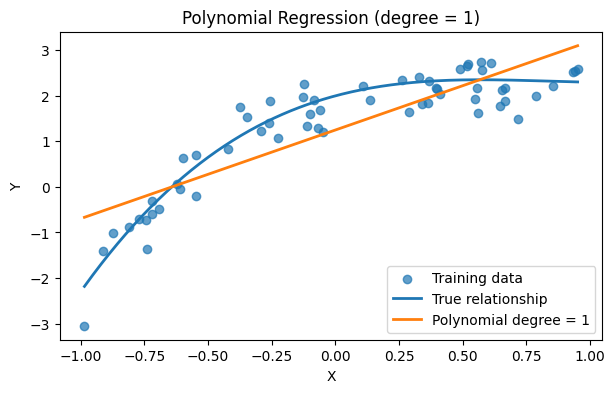

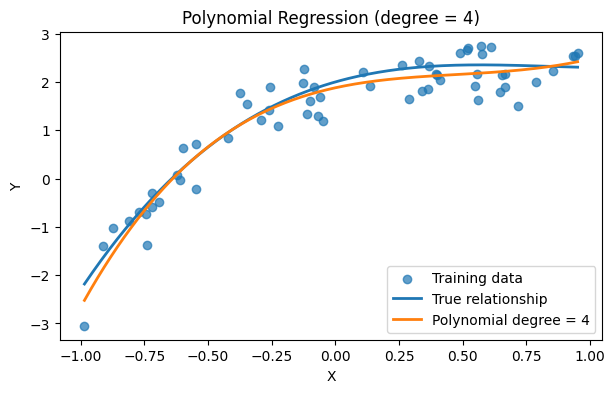

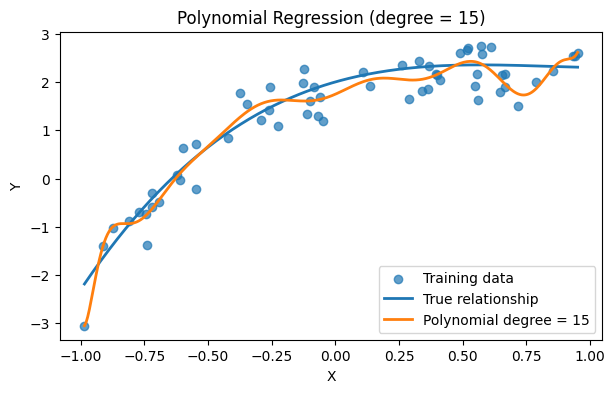

In [18]:
# True relationship used only to create the simulated data
def true_f(x):
    return 2 + 1.5*x - 2*x**2 + 0.8*x**3

rng = np.random.default_rng(42)

X_demo = rng.uniform(-1, 1, size=60)
y_demo = true_f(X_demo) + rng.normal(0, 0.5, size=60)

x_grid = np.linspace(X_demo.min(), X_demo.max(), 300).reshape(-1, 1)

for degree in [1, 4, 15]:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )

    model.fit(X_demo.reshape(-1, 1), y_demo)
    y_grid = model.predict(x_grid)

    plt.figure(figsize=(7, 4))
    plt.scatter(X_demo, y_demo, alpha=0.7, label="Training data")
    plt.plot(x_grid.ravel(), true_f(x_grid.ravel()), linewidth=2, label="True relationship")
    plt.plot(x_grid.ravel(), y_grid, linewidth=2, label=f"Polynomial degree = {degree}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(f"Polynomial Regression (degree = {degree})")
    plt.legend()
    plt.show()

### Check your understanding

For each model above, decide whether it is closest to:

- **underfitting / high bias**,
- a reasonable balance, or
- **overfitting / high variance**.

**Questions**
1. Which model is too simple to represent the nonlinear pattern?
Polynomial degree = 1
2. Which model follows small fluctuations in the training sample too closely?
Polynomial degree = 15
3. If we collected a new training sample, which fitted curve would you expect to change the most?
Polynomial degree = 15 because of the high variance and

## Training error vs. validation error as complexity increases

Training error generally decreases as model complexity increases, while validation error often decreases at first and then increases when the model begins to overfit.

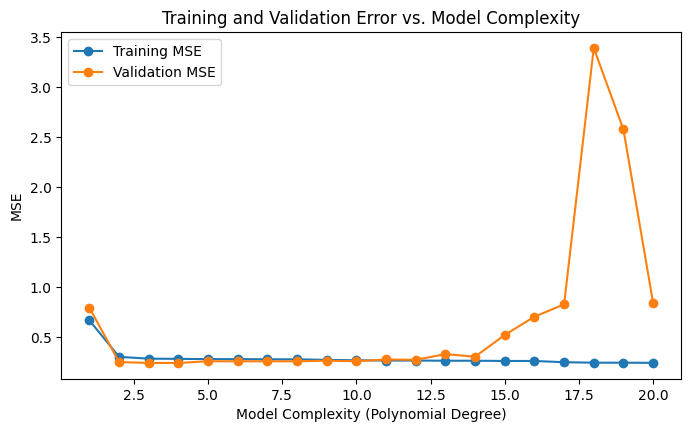

Degree with the lowest validation MSE in this split: 4


In [19]:
# Create one dataset and split it into training and validation sets
rng = np.random.default_rng(7)
X_complexity = rng.uniform(-1, 1, size=160)
y_complexity = true_f(X_complexity) + rng.normal(0, 0.55, size=160)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_complexity.reshape(-1, 1),
    y_complexity,
    test_size=0.30,
    random_state=42
)

degrees = range(1, 21)
train_mse = []
val_mse = []

for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        LinearRegression()
    )
    model.fit(X_train_c, y_train_c)

    train_mse.append(mean_squared_error(y_train_c, model.predict(X_train_c)))
    val_mse.append(mean_squared_error(y_val_c, model.predict(X_val_c)))

plt.figure(figsize=(8, 4.5))
plt.plot(list(degrees), train_mse, marker="o", label="Training MSE")
plt.plot(list(degrees), val_mse, marker="o", label="Validation MSE")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("MSE")
plt.title("Training and Validation Error vs. Model Complexity")
plt.legend()
plt.show()

best_degree = list(degrees)[int(np.argmin(val_mse))]
print("Degree with the lowest validation MSE in this split:", best_degree)

# 2. Bias–Variance Tradeoff

For a new observation at $x_0$, the expected prediction error can be decomposed as

$
E\left[(y_0-\hat f(x_0))^2\right]
=
\underbrace{\mathrm{Var}(\hat f(x_0))}_{\text{variance}}
+
\underbrace{\left[\mathrm{Bias}(\hat f(x_0))\right]^2}_{\text{bias}^2}
+
\underbrace{\mathrm{Var}(\epsilon)}_{\text{irreducible error}}.
$

### Sources of error
- **Reducible error:** bias² + variance
- **Irreducible error:** noise in the outcome, $\mathrm{Var}(\epsilon)$

The goal is **not** to make bias or variance individually equal to zero.  
The goal is to choose a model complexity that gives good prediction performance on unseen data.

## Simulation: what changes when we repeatedly collect new training sets?

We repeatedly generate new datasets from the same true relationship and fit models with different polynomial degrees.

At a fixed point $x_0$:

- **bias²** measures whether the average prediction is systematically away from the true function;
- **variance** measures how much predictions change across training samples.

In [20]:
def simulate_dataset(n=50, noise_sd=0.5, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, size=n)
    y = true_f(x) + rng.normal(0, noise_sd, size=n)
    return x.reshape(-1, 1), y

x0 = 0.30
noise_sd = 0.50
n_repetitions = 300

summary = []

for degree in [1, 4, 20]:
    predictions = []

    for seed in range(n_repetitions):
        X_sim, y_sim = simulate_dataset(n=50, noise_sd=noise_sd, seed=seed)

        model = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            StandardScaler(),
            LinearRegression()
        )
        model.fit(X_sim, y_sim)
        predictions.append(model.predict([[x0]])[0])

    predictions = np.array(predictions)

    mean_prediction = predictions.mean()
    bias_squared = (mean_prediction - true_f(x0))**2
    variance = predictions.var()
    irreducible_error = noise_sd**2

    summary.append({
        "Degree": degree,
        "Mean prediction at x0": mean_prediction,
        "Bias^2": bias_squared,
        "Variance": variance,
        "Irreducible error": irreducible_error,
        "Bias^2 + Variance + Irreducible": bias_squared + variance + irreducible_error
    })

bias_variance_table = pd.DataFrame(summary)
bias_variance_table.round(4)

,Degree,Mean prediction at x0,Bias^2,Variance,Irreducible error,Bias^2 + Variance + Irreducible
0,1,1.9223,0.1364,0.0154,0.25,0.4018
1,4,2.2849,0.0000,0.0174,0.25,0.2674
2,20,2.3042,0.0002,0.1400,0.25,0.3902


### Interpret the table

1. Which degree has the largest **bias²**?
1
2. Which degree has the largest **variance**?
20
3. Which model appears to give the best balance between bias and variance?
Model with degree 4
4. Why does the irreducible error stay the same across models?
Noise is constant

# 3. Model Validation

Model validation estimates how a fitted model may perform on **unseen data**.

The basic workflow is:

1. split or partition the data;
2. train the model using the training observations;
3. evaluate predictions on observations that were not used to fit that model.

We will compare:

- **Train-Test Split (TTS)**
- **K-Fold Cross Validation**
- **Leave-One-Out Cross Validation (LOO)**

## Example data: Amazon books

We will predict `Amazon Price` from several book characteristics.

The preprocessing step is placed **inside the pipeline**, so scaling is learned from the training data for each fit rather than from the full dataset.

In [21]:
# Load data
ama = pd.read_csv(
    "https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/amazon-books.txt",
    sep="\t"
)

ama = ama.dropna().reset_index(drop=True)

predictors = [
    "List Price",
    "NumPages",
    "Weight (oz)",
    "Thick",
    "Height",
    "Width"
]

X = ama[predictors]
y = ama["Amazon Price"]

print("Dataset shape:", ama.shape)
ama.head()

Dataset shape: (310, 13)


,Title,Author,List Price,Amazon Price,Hard/ Paper,NumPages,Publisher,Pub year,ISBN-10,Height,Width,Thick,Weight (oz)
0,"1,001 Facts that Will Scare the S#*t Out of Yo...",Cary McNeal,12.95,5.18,P,304.0,Adams Media,2010.0,1605506249,7.8,5.5,0.8,11.2
1,21: Bringing Down the House - Movie Tie-In: Th...,Ben Mezrich,15.00,10.20,P,273.0,Free Press,2008.0,1416564195,8.4,5.5,0.7,7.2
2,100 Best-Loved Poems (Dover Thrift Editions),Smith,1.50,1.50,P,96.0,Dover Publications,1995.0,486285537,8.3,5.2,0.3,4.0
3,1421: The Year China Discovered America,Gavin Menzies,15.99,10.87,P,672.0,Harper Perennial,2008.0,0061564893,8.8,6.0,1.6,28.8
4,1493: Uncovering the New World Columbus Created,Charles C. Mann,30.50,16.77,P,720.0,Knopf,2011.0,0307265722,8.0,5.2,1.4,22.4


In [22]:
# Helper function: build the same linear-regression pipeline each time
def make_linear_pipeline():
    preprocessor = make_column_transformer(
        (StandardScaler(), predictors),
        remainder="passthrough"
    )

    return Pipeline([
        ("zscore", preprocessor),
        ("linearregression", LinearRegression())
    ])

## 3.1 Train-Test Split

A Train-Test Split creates one training set and one test set.

Below we use an 80/20 split.  
The fixed `random_state` makes the example reproducible.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

tts_model = make_linear_pipeline()
tts_model.fit(X_train, y_train)

y_pred_train = tts_model.predict(X_train)
y_pred_test = tts_model.predict(X_test)

tts_results = pd.DataFrame({
    "Set": ["Train", "Test"],
    "MSE": [
        mean_squared_error(y_train, y_pred_train),
        mean_squared_error(y_test, y_pred_test)
    ],
    "R2": [
        r2_score(y_train, y_pred_train),
        r2_score(y_test, y_pred_test)
    ]
})

tts_results.round(4)

,Set,MSE,R2
0,Train,10.7268,0.9249
1,Test,11.7299,0.8793


### Interpreting Train-Test Split

Compare the training and test results.

- If training error is high **and** test error is high, the model may be underfitting.
- If training error is much lower than test error, the model may be overfitting.
- A single train-test split depends on which observations happened to be assigned to the test set.

## 3.2 K-Fold Cross Validation

In K-Fold Cross Validation:

1. split the data into \(K\) folds;
2. use one fold as the validation set and the remaining \(K-1\) folds for training;
3. repeat until every fold has served as validation data;
4. average the validation performance.

Here we use **5-fold cross validation**.

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

kf_results = []

for fold_number, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    model = make_linear_pipeline()
    model.fit(X_train_fold, y_train_fold)

    pred_train = model.predict(X_train_fold)
    pred_test = model.predict(X_test_fold)

    kf_results.append({
        "Fold": fold_number,
        "Train MSE": mean_squared_error(y_train_fold, pred_train),
        "Validation MSE": mean_squared_error(y_test_fold, pred_test),
        "Train R2": r2_score(y_train_fold, pred_train),
        "Validation R2": r2_score(y_test_fold, pred_test)
    })

kf_results = pd.DataFrame(kf_results)

display(kf_results.round(4))
print("\nAverage across folds:")
display(kf_results.mean(numeric_only=True).to_frame("Mean").T.round(4))

,Fold,Train MSE,Validation MSE,Train R2,Validation R2
0,1,10.7268,11.7299,0.9249,0.8793
1,2,8.8410,22.9203,0.9077,0.9195
2,3,11.5597,7.1282,0.9286,0.5355
3,4,10.2510,13.3969,0.9325,0.7806
4,5,10.0005,14.3429,0.9134,0.9290



Average across folds:


,Fold,Train MSE,Validation MSE,Train R2,Validation R2
Mean,3.0,10.2758,13.9036,0.9214,0.8088


## 3.3 Leave-One-Out Cross Validation

LOO is an extreme version of K-Fold:

- if there are \(n\) observations, fit \(n\) models;
- each model trains on \(n-1\) observations;
- one observation is held out for validation.

Because each validation set contains only **one observation**, we calculate the overall LOO MSE from all held-out predictions rather than calculating \(R^2\) separately for each one-observation fold.

In [25]:
loo = LeaveOneOut()

loo_actual = []
loo_predicted = []

start = time.perf_counter()

for train_idx, test_idx in loo.split(X):
    X_train_loo = X.iloc[train_idx]
    X_test_loo = X.iloc[test_idx]
    y_train_loo = y.iloc[train_idx]
    y_test_loo = y.iloc[test_idx]

    model = make_linear_pipeline()
    model.fit(X_train_loo, y_train_loo)

    loo_actual.append(y_test_loo.iloc[0])
    loo_predicted.append(model.predict(X_test_loo)[0])

elapsed = time.perf_counter() - start

loo_mse = mean_squared_error(loo_actual, loo_predicted)
loo_r2 = r2_score(loo_actual, loo_predicted)

print("LOO MSE:", round(loo_mse, 4))
print("LOO R2 :", round(loo_r2, 4))
print("Number of fitted models:", len(loo_actual))
print("Elapsed time:", round(elapsed, 3), "seconds")

LOO MSE: 13.8492
LOO R2 : 0.8964
Number of fitted models: 310
Elapsed time: 2.765 seconds


## How should we choose a validation method?

The lecture emphasizes two practical considerations:

| Method | Number of model fits | Main idea | Practical consideration |
|---|---:|---|---|
| Train-Test Split | 1 | One train/test partition | Fast, but the estimate depends on one split |
| K-Fold | \(K\) | Rotate the validation fold | Uses all observations for validation across folds |
| Leave-One-Out | \(n\) | Hold out one observation at a time | Uses almost all data for each fit, but can be computationally expensive |

When choosing among them, think about:

- **dataset size** — both rows and columns;
- **computational expense** of fitting the model.

### Quick question
If your dataset has 10,000 rows, how many models would LOO fit?  
10000

How many models would 5-fold cross validation fit?
2000

# 4. Regularization

Model validation can help us **detect** overfitting.  
Regularization can help us **reduce** overfitting by making a model effectively simpler.

For ordinary least squares, we minimize squared prediction error:

$
\sum_i (y_i-\hat y_i)^2
$

## Ridge

Ridge adds an $L_2$ penalty:

$
\sum_i (y_i-\hat y_i)^2
+
\lambda \sum_j \beta_j^2
$

- coefficients are shrunk toward zero;
- coefficients usually do **not** become exactly zero.

## LASSO

LASSO adds an $L_1$ penalty:

$
\sum_i (y_i-\hat y_i)^2
+
\lambda \sum_j |\beta_j|
$

- coefficients are shrunk toward zero;
- some coefficients can become **exactly zero**, which can perform variable selection.

### Role of $\lambda$
- $\lambda=0$: no regularization penalty;
- larger $\lambda$: stronger penalty and more shrinkage.

## Compare Linear Regression, Ridge, and LASSO

We use the same training/test split for all three models so that the comparison is fair.

In [26]:
# Use the same split created in the TTS section
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 60)),
    "LASSO": LassoCV(cv=5, random_state=42, max_iter=20000)
}

regularization_results = []
fitted_models = {}

for name, estimator in models.items():
    preprocessor = make_column_transformer(
        (StandardScaler(), predictors),
        remainder="passthrough"
    )

    model = Pipeline([
        ("zscore", preprocessor),
        ("model", estimator)
    ])

    model.fit(X_train, y_train)
    fitted_models[name] = model

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    regularization_results.append({
        "Model": name,
        "Train MSE": mean_squared_error(y_train, train_pred),
        "Test MSE": mean_squared_error(y_test, test_pred),
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred)
    })

regularization_results = pd.DataFrame(regularization_results)
regularization_results.round(4)

,Model,Train MSE,Test MSE,Train R2,Test R2
0,Linear Regression,10.7268,11.7299,0.9249,0.8793
1,Ridge,10.7268,11.7297,0.9249,0.8793
2,LASSO,10.7717,11.5078,0.9245,0.8816


In [27]:
coef_table = pd.DataFrame({"Predictor": predictors})

for name, model in fitted_models.items():
    coef_table[name] = model.named_steps["model"].coef_

display(coef_table.round(4))

print("Selected Ridge alpha:",
      round(fitted_models["Ridge"].named_steps["model"].alpha_, 6))
print("Selected LASSO alpha:",
      round(fitted_models["LASSO"].named_steps["model"].alpha_, 6))

,Predictor,Linear Regression,Ridge,LASSO
0,List Price,11.8006,11.8005,11.6293
1,NumPages,0.1608,0.1609,-0.0000
2,Weight (oz),-0.7009,-0.7009,-0.6450
3,Thick,-0.8084,-0.8084,-0.6266
4,Height,-0.0837,-0.0837,-0.0000
5,Width,-0.0611,-0.0611,-0.0000


Selected Ridge alpha: 0.001
Selected LASSO alpha: 0.086387


### Regularization questions

1. Which model has the strongest coefficient shrinkage?
Lasso
2. Did LASSO set any coefficient exactly to zero?
No
3. Does the model with the lowest **training** MSE necessarily have the lowest **test** MSE?
No
4. What happens conceptually when \(\lambda\) becomes very large?
Coefficient becomes zero
5. Why should continuous predictors be standardized before comparing regularization penalties?
Training data will converge faster

# 5. Classwork

## Part A — Train-Test Split

Use:

`https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/kc_house_data.csv`

Build a linear regression model to predict `price` using:

- `sqft_living`
- `yr_built`

Requirements:

1. use an **80/20 Train-Test Split**;
2. use `random_state=42`;
3. z-score the predictors inside a pipeline;
4. fit the model using only the training data;
5. print **Train MSE**, **Test MSE**, **Train R²**, and **Test R²**;
6. based on the train/test results, briefly discuss whether there is evidence of underfitting or overfitting.

In [28]:
data = "https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/kc_house_data.csv"
df = pd.read_csv(data)

X = df[["sqft_living", "yr_built"]]
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Train R²:", train_r2)
print("Test R²:", test_r2)



Train MSE: 61999361981.43487
Test MSE: 72280562272.51794
Train R²: 0.5254495229550811
Test R²: 0.5218803134856528


There may be slight overfitting occuring since Train MSE is sligtly lower than Test MSE, but the Train and Test R^2 are very similar, meaning the model performs similarly on both Train and Test (not a lot of overfitting).

## Part B — 5-Fold Cross Validation

Modify your model from Part A to use **5-fold cross validation**.

Requirements:

1. use `KFold(n_splits=5, shuffle=True, random_state=42)`;
2. report the validation MSE and R² for each fold;
3. report the **average validation MSE** and **average validation R²**;
4. compare the K-Fold estimate with the single Train-Test Split estimate.

### Questions
- Why might the results from a single TTS differ from K-Fold?
- Which method uses each observation for validation at least once?

In [31]:
data = "https://raw.githubusercontent.com/ywen2021/CPSC392/main/Data/kc_house_data.csv"
df = pd.read_csv(data)

predictors = ["sqft_living", "yr_built"]

X = df[["sqft_living", "yr_built"]]
y = df["price"]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

kf_results = []

for fold_number, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
    X_train_fold = X.iloc[train_idx]
    X_test_fold = X.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    model = make_linear_pipeline()
    model.fit(X_train_fold, y_train_fold)

    pred_train = model.predict(X_train_fold)
    pred_test = model.predict(X_test_fold)

    kf_results.append({
        "Fold": fold_number,
        "Train MSE": mean_squared_error(y_train_fold, pred_train),
        "Validation MSE": mean_squared_error(y_test_fold, pred_test),
        "Train R2": r2_score(y_train_fold, pred_train),
        "Validation R2": r2_score(y_test_fold, pred_test)
    })

kf_results = pd.DataFrame(kf_results)

display(kf_results.round(4))

print("\nAverage across folds:")
display(kf_results.mean(numeric_only=True).to_frame("Mean").T.round(4))

,Fold,Train MSE,Validation MSE,Train R2,Validation R2
0,1,6.199936e+10,7.228056e+10,0.5254,0.5219
1,2,6.281226e+10,6.911510e+10,0.5225,0.5322
2,3,6.470002e+10,6.148901e+10,0.5266,0.5164
3,4,6.473542e+10,6.133685e+10,0.5228,0.5326
4,5,6.598502e+10,5.643859e+10,0.5265,0.5154



Average across folds:


,Fold,Train MSE,Validation MSE,Train R2,Validation R2
Mean,3.0,6.404642e+10,6.413202e+10,0.5248,0.5237


The average validation MSE for K-Fold was 64,132,020,000, compared to the Test MSE of 72,280,560,000 from the Train-Test Split. Therefore, since the MSE for K-Fold is less than the MSE for Train-Test Split, K-Fold has a better estimate.


TTS just uses one cut of the data, 80/20 for training and validation. So, it has one training set and one validation set. However, K-Fold uses K validation sets and averages their results, so the resulting estimate tends to be more representative than TTS.


K-Fold uses each observation for validation at least once.

## Part C —Regularization

Use [this web app](https://shinylive.io/py/app/#h=0&code=NobwRAdghgtgpmAXGKAHVA6VBPMAaMAYwHsIAXOcpMAYgAIAhbOgYQAs4AbAZzijoAKUAE6c4ZMoK5jhASzKyAOhGWyYqYsMkwoZVJ2JlOsgEZZs+w3Sjc6+ssuX0Akus3biAEwCuY2wDNNOhgvLlkIAHNVNy07KAhPG2tbVE9ojVjeKBNNCGS6bghuRwgXGMlCb24yYhhBbDI2UjoAMW8IQgVSAOFaugNCKE46f1kxZX9eupJ1ETg6NQyK2tQ5vAK1AH1EsigJqYK2cOZF9zoAQXR15whUbzJudYB5e7uH9YBlOG5uWVJ14R8TqyABucABlE8cGE628ShUpToOz2ECKalsAF46ABGAAMuOUvzqWOARO2uigAAoIBi8fiAJQjIKyBZ5YTxCJwSm49ZomDcekAXRKTms6GUaFQmzhdCxcKwUE5m1GAA84J5Kco6Nq6PQoJ5PHQOPq6I1dNZOAYAO62AAyUAAKnAABqm4h0EzzTyybj6KDYdV0EGyfgAWV0bAAUlAVVqdfLjZ5NiRyJQyJq8jqs-LdhFuBhuIQ5Kh03Gs+WCsJCBjFGA2BJUNxEAB6Zs6RoAKxjGGE1W83uIGBmzc4um+ZGb4ca0ZVGA73AA-CnRhEMU7nQBac6hj4b0Oh22bAASDoPmn3ttrZfL9Lw1+zsgwufzheLpczFaztdk-jolKt4SeMQVoYFOUYxoyYEzhgR7eGYACK3hwEhlLAAA5A6FjfOIaHrFB3awSYgr0gA3FeH43neFG3te8okJw3gwBAGafjiPL3jqIC1oQo4-LWiB0NxxCcBuMCeBueJ0PRG6cBEG4ABx2NgG4AKzBCqG5QPc7oUCqZAyXJhBptCppwHpMlwP4DhgAAvlRrH0A68jjBRD4YGw2KamAR7AXQAAixDfHQABKcARL4IiyAAXrofx5B8ZCApEjQXP4-hwJ0rCBWlsiELIaZ0AAotUahjoutY0a5Or0OEbwFMYULCNelVufRjHMRx2p4vZn5cUQvHFEgglEMJoniQA7Ip0myapSkbgALOpmnabWdmdbqdBOUYcDrfKtX3Js3ANdCLGsTqtZ7Pg61fmAXxiJl-CheFo5yDFXTxYllARI0iC1j1Z10LiGD4iDIPYv9Z3g9dOpA1DVUVtUcCoBiQO4nDAPagBniNDWYB0gApH960tZ+8qoKdAN9TxNiDQJtYlgtBQ6Jaq0Q6xtaUoVUCEGwppqPM2DEN4UlsBy8yNPMR2yI1rJvOsEsbDAEXvXQAGWqaUAANaS7U4v826dDCO0GD0kT8N0CT2qW3QdHCe1FPltiABMbOcdxA38cN01ydi2JzWpMAaVpNSs+t9BC3o9x2AYDjm-KEdvJslilmAycVRD1v0IVKp+tAKvxIa2eWICpl6YbvkASlZBWu6cAAI7eEMG5YylbVMcUFHyr0VoO61dtMb3n7ddD2pUx7Q1CSJM0AGz+0twfEKH5tuWw81eUXo553F6cjzbj7k7vN1XmAh86gA6hweRWuL7LhHQ4Y8+E8y2nwwgQOEETBKEPD9LI2u-xAV+hswqAh+HFR4-RiARB9AoQgp9tSAgiKA343R1hBEAd4dkwxAHV00JrCB18kTum4O6EwzAoSjHfpEawkCfgjHaMCUg8DrAJGCOENQ0UP6mlFpIAwdD-AMPehgC4tCAiCLigsWw-B4CJVykyJqy9PzwBsJgrhTQrR0EFpgr+UJhg+jsNCQIwgYBcKtBwEu1oTL6M9BIaEwiWiaGYWZWA+hwT3z4PFBucxC7CF6MISRNC+FiI6CrM02g+DcEwUFBW3AvGAjSIois3pqjxCMn+ZoUAwTsk5IyGx19KA0JCLotCthwrfF4FI1hCtEpISDEMJC+Zj7kQxhbV2FZ6D2nXLvMmXkAAkvSdyFVlIJRQozJjcxANiGyIAIA2RGaMyJMBNggFkLSGyAA9GZczKQAE1Ngsg3CMnhIAdk2X2fSdZTt+k70SXvLAg8AZNJPrcrMT0IqvVis0Guwh8EemYPqb01D+CoEoEMMgzAajcPmEE+hISJF300I1ZhkKQXQGMFFaFIhOQ6K4HEdkMjoT5joDcOgton4iBCiA8pcV5YcAMWi8FzDwhFgiUFMxBSYnRXmMQX8CsSCWVGHlNMthmWAhsN8YRDAMpaV4FC0RzCBFwuaPonQUIbaoDoDy00NduEfybHKzQshoFotEbCxheRKQK0GW0s65i4CMgLnK1FYLsDrFQPE3KNRezBCqJINCdx1YS1kP46+Rr6xoT+cAnweVIjIrpYMuglAhYRF5pCz0dA0LfMaBGhWzrODguEQ6I4thBhVCCtwZmnBYTv3KPEWOLSszuvVJ6zQthIWizBEzIYwwggYt6FJbKgr8rkEaSfMdu9rasR6cwp5zDbTnA+B8J4f5bTYgdaw4K0tsWUltE7B1JdcEDpgCEPIRj+Sat-G8l60VPkQGEfOxdTxmEAqkfSl1BsFYwsVeayNuxNZcIVtkEhDEKB1IYty38QI2DMNWPi8Q0Jmz8pykK8g6xHUAoAxwOo3a3ScglsIYRm7PDYpfdYGDoL80Qp0nSr94jmhkI1v+6hMS4kQcTdzaDLydSwdgPB4QiHB25WHWQNDrCMPMawxaYYNQ8PmIwLO25k7PwdMdC6bp+8HlnVrP0h9S7hmjLGeyQgkzpmzPmYoRZyzVlTM2WZ3Z+y6CHNGcc055zLl0AANTmdHDAEwiRzPtEaiYIzcAuIGcsyADsazNmoDmQAHwM4oGxUBNgdji2cxLukyAgDzeCmy1znktKUxWadXHtTad6UR7FWJEvjOM1MrZ5mIvWY2Y1+zByjm6BOWc2QFynaee87APz-BEuBehMF7moXEsRaizZnLczEvJdS5cjLBmss5Yo3lgrE6bVuQPmV4aTSDsXwKVULhiD3k3veusQhStqgi2IMQWVCsLvXrehI6oSVvqcYbTqSkvBJbHX8dkYgYJGRmNyrzfR-AICMU9P4sJBRBh+CNL5UWvY2CcGYNfcjaKuXCOcL+W7vgFD6AhXS3LzAGM8m4boEpcruC8fyBAKwHaP7PrfZR6wkhu2Sqjj+VW8wlb5tkGTp1m2qfMBUviWl5oa6+ASb97UeauVOpELxig3r+Axy-oCeT47CsY2K+WadYBrkGZ88N8z62AkvbCpd97zRPtfUaBgfLvSbmsWttbLuwFNO2wYgPXew9bljxpp7SeBkNyzxwLNQOy0Q62V2-GR8q9145wMICT3GMEwqS8iwFYkVqG6aeOsKrbjHVksARSp6yDt5gGN3tzT7MDfMLPvIVNdKpYy3NLDP8CsKFaXzYyAwxBNbc7lTkDPVhzTVOIBqnlcb5irE5IW4thxgJtrpUhodwqRgHDpLiRWytAzIgKOIIlDiFFK-YzzJEFJz+SAVmhEEwEuDcAjZSc46xCrXGeOsAAVXWB2XWDPkZCAiNEyR1ngGYUBFHHem4COA1Urk725XuBmHmEpGdEZERyFn8SKVxX0SbW9GBEiGEXOEgI7hv0-SxXHETTSgyif0viKj-zoFLzoCALoB2RYUNEoW7WYDPkoIZ0rXHCcQYMymaGdDX3mALyKFIDrVsEpAYDwBYDwD8jwAAHE8Ajw8BIw8AABpRkDteYIDO2CgLHOgFneg9KCQhEG-KQhTIrZPbUU3W0R7cfWfOlDQ9kVAXmdDbgcfLRXsLgXlDgWVBucccBX6BvZwu5Z8DAXwZvUmR8eI4wJIx5VvA7ViC+SHHFYYHdclGEUlBdJdMvLde1UyBINtd0YwuVI4FNUQrIz8HfITYVBcOgC+c0ICaJdfcw4YLRawHIKOBWEESKIWKgm-T8XLfKWwKDPIyghcRwpXRvZIp8RUfMNI5hI+cdJoisToyQUWdASgaouVEvAdAVVokdeROVWQkhaAcgLYqYj1ToVtP8BgDcQw1WI4O-WoqwsVYYAVRgzVPIZ0RYzIm-FYkrFI9YjATY3Yw7HYyYz8ItZ+QongkKcorKC4lDB4SBMfRWMYClIxKFR4isW4+Qq4pQj43JKOMxOnWwKWFNIwchH8dKJKSQPJOADlLDRY+ErMfYohHo2faQTRIWQYiOL480cvTnBQIKICMEo7CE2ItyVI2QdIrTcEpE8sc4A9GjWg-xQEzoRQ84DcZwB1cQigQ0b0Bg9kiws0PICWUk8sCtbtEyQ03EykJ4DcMAr4gpAY0VVlOVK9SKR3OwrUrMBKL7RoBUxE5Y2IyEu5NgPPWsAvWYOQahPyVk6EAqYMj5FWSMl3NgQaBM0rG-JY37AAOWAlhF+Ak0B2lhMk8PFnnwvTV05HWB5jFiDPtze1vWYQLOSjYELWEGYFGPAy33NDmCDGhGYGtHWAIPZAoFE0NCyWYHqKHPLLOhLI01rDcPxKbLoG8LQD8LEwCNFMwV4E4FCOwjoAiJKm6GiO3LWLzASM4HVJVJhLhPDM3JvwFMONRROIVjOMdWlIIJ-nZQdLpVzKu23nhIHO+wCSGBCHu1xBjOaTjOYRzE-LVKdJ-KVz-MlGOI-TpTOLAvpxaJxNsAgpJPhOgtDLoHgpSn0VXKNDDTQsN1+wTI-JfK-K1Lwt+wClOLRNr2pWaAouExLVFkiHmGooGM7OkqdLotvQYs+kHPaMpAFxIRuzYFdQWF-BZxEy+OYAMoXFNk1M4vjJtW9whnDleCjmTgZKRnV0tMjX+OsMYMUNf2vh4FvHRL7WIA3HdMUJTDuIUNNk7kfDbg6nNmdhtTDz4gnhGinh9j9ljwDiDm0lLn0iMlTCaiT12lTydi8gEBjlsC+B4xcoYwADU38f5HVyT7iHhs8rYIYA97Z1pYr1p4raYvZRoZpfZggTBZpUAhr0qE9F58q45HwE4Dpk4vJk4qqngz5CpbQPhmqTdpq7KyAk4Y55qY4WAngKyl0KzzgKyHQ1qYjmoqJwqSgKFz9hAskNLbh7gBIbg3gIEZqyABIXhI53hz8wFSABIvgAaIB6RfoKJ6AxVgRO0WAhhCBadJAjYihijH0yjiMK9WEq8gEwLbBmhORAFFzT8KRrwAABKGhQMEDAWGzgOBCiO6nGykMG9aMkIYXw-gEkGYWDLkTwfwNDTgNmjEfaMgDAKkekRkYknm1kRWYUc2Fm-m0WYZVIIcUgQYdMOWtmm682QEMgTBPIdW0WEoLMWy366OKwLVHDIkZWCRcS4VUmz60mpKRqLAXa8KrMO6uapm82egPDe-XYffPocm0EGQuG5mrYVmhWrEBmzWhyKSMVUDZOdEnQaAEjccDgWBCYisFcNDFURW-NAsOCByxm9aGMfrLEQofMKfOa3eFUXGFMXjQaWI7AWu7KBu3eNgJCXGMCs2FpZEDEfWqAWImMDEGMWIxFaEDEYAGdMAc4bupXWsQqWe37WsZwRehtWsJ9K6A7WsAA1elpWsHZXejGWsM+Q+jIhgU+jUlgC+lvPya+z8WsDQu+isWsI8J+8sWsSMN+m6fQt+wUKy9aCQfTMAAvbE4TIqEqdsNlZg8O9m4aAbT7J6t4EWxm12z8EugscQSkFUUcT0TgXGP6TRHBrgXGEB5DMBqq+pHafAPmbaDECQVBisbW3WkYI1Q26qTVLa02yQc29WS2+A62wTSiv8Ly9-YErHBhugEm+2iiMmyEOxD268d2mORa5a1axm8GmOn2s-SYAOoECm4Omm0OpZGB4ZKO9aERn+EkPIO+Se6egh+e+xsAFe6h9exxnelxsAA+jxk+sAQUa46xvWsO+WqAZW6AeAbgGW1ifuzYKq4Zfu2E4gQgYACxiJth9pWOvgeOnXR1JOxUEw1O8QXKDO8sLO6wHOrEewfOkwQuiRrMEuuJooDASu3a6u5usJ74N+puoSSyVu25duuATu7+N+3u6Jqqwemuke3eMe4QCe2sGejxhejx5x9YVxjx9xlZzxxxnxv+4mAByQGrMAFRlarEshgqYqBQSBqi6B4JoB+BxKRB+4ZBsW4ulUJ2DB9MbB7IYh4+dYbAIhvBlMwR8hyhghhQWh+h9aJht+FhqIMM7UY2uqBOnh4YPh5Sm2ykkKik3E0gcRu2rah2uRgjBRumyyLhg6o6w606869RsOOgLRh-HRuoQOmGkO2WoJtm0x7+bgIuuF8sTFxqzEOgSe25AJoV2sc+jxq+jx2+jxx+jx1+jxz+jxn+3x-xqW+Juu8J9aSJz8aJlgOJ9l0WBJpJ-lhQmW2lllMcLhxO+IPJ6wAp9O9aUpmMXO4WyJap0qnl1iepsuxp5pwwdUmuoSdp3plpLpkaHpt+-pwZ3RYZikPuw1lLVQ3eIeyZ25aZ2ZsACVjZqVjZmVjZuVjZhVjZpVjZlVnZ82WpnUQBg58l46qlk53fcgcBi5sqX0vIExg5u54QB54W0Wqt7UdB3gD5-5-B6hv5r5gF4BoFgqCh8DUF5yAZiFrW8QZhlcEUaAdAYZS4cmSUaUWQdYXgB66EcKpPcAdp6gTmuYcwfAEaVMKgZAU4WIWHdQf5WwW4dIM4VYBIJIJIVIfYPoAIsQEQO9YwavYQTYMChYcoUlQokSkGtG9s0lGmYgH-XiWBCs8QEoegChJ+M1BA5QO6skZEakWkEGT2o2ylIYOgChuQbIPwa8CgrEW4HsAuWoDAFnYxIYbkdYcGSwiRoZZjzAdkBIdjzj5mHjnEXkCR5wYZFjkToCGADjzQCTmnPj0G68ZdIT1j0TpT8T7jtT6T68AAuT4TtjvTlTgz3joziibg7ThTsTyzt8wz-j68QQ+z8z5Trj5z6z1z3l+gAAiAOAscQ0WjkMEwBjiiBgUznTxTrz1T3zjTiifVjz3T+LqzqTvzrMPyGLhziz7zyT9TiRjQ3Lzz-TnzzLpLrMI8UrtL8rwrmzrMSMWruL+rlzqrnUfQlrxzgr9r6O9h9FpqiiWB52DAAAZnmmvHmCxHkgwCdjG+vBZCxHGgwHkgW4ondCxBUgwGdlomGTG4wHmnkmvGYCxDeYAE5xprwNEsRsRxvjv-O2D0DdZrxXQsRNM6R1ovMKCAAqMjc2LzIZP7naAH4lOgP7+EViLzZdP7xeUHkzv77wL7rg8HzRZHwQv7q0ZH+TsrpzwrlSRrnUfr7UN7v8V0Q5Fj5RZibAxkZsSwzAaoDUbA+FugKKDcQsTQeYZ0a8egBWQwcxOpOjiLoKIYMVTwNcqAwpDxVso-R1bgQ0LVbENJjaPyB-FoODRR38CpzwDAVX3YdX3jTTLiW5OZz2b-XeBxoaX-C3pxz2ZwWI1Z76h3sAdxgSIAm3iVgSZQm3qVgSZNk3sAGVgSdQm3uVgSLQm3hVgSHQm3pVgSPQm3lVgSfQ53rxgSEAm3nxgSM+Z37noaZ0G1GyZqa8KFvIHmjdu6q9wESkHmvmgWtdDRnUdKc0EkU3jx7N4aXN4afN4aRZgtxx4t4aZZ4aDejZ9Z4aUt4aFVjZrxjZ7Z5X+gMD1+a8TgfxLELGkQeDlBZiCR1fjAUYdMHm4AZvsgP+pEfwWxvP4iFfiDkgYZPfpDTYBf-oFDlflD4Ze0H4YgSkGB4e4J9YA-vslypGQSwa4I2G4hqB4NUYoMNGPORjD7JNcZHUGLvxQ7795ANfC-ifzP5H9awV-FAV-2TCbcX+X-ZWpZCf6Pc5A6NEvpiSxDl5NMv-HmgWEOJwBgAuIPxn9xgYAD5AQAzXCALIBgCkI8sYSCjGBgwC+OOgFUAgPHqH58QxfCiJQNXwH8MBx-TJtgIv64Daw1-eQeUUIHDIFBcAUgf4HIHXhNWQULECf1R7rcswSGQVixxTCq1QUFAVCKv0IHrABoxAVwYbB0EkAtB14KDvZyRiZNNMLHEQOyGwCoRdyhRRxiXkcbl5NBxuYAGIGYgn9fKSQykCkLcGUB0hmTIUDahjA+gUYGcZXpLW1668KQBveAJSCpjyEtWQ0UwRAm6b+AeqNgjZl3SGhgUbIxPYBDrWhbl8IAtkQUEAA) to play around with the regularization strength of the models. *MAKE SURE to scroll all the way to the bottom to see all the graphs*.


### Questions
With the slider at 0.1 (the default) look at the boxplot at the top of the page. This shows the coefficients from 1000 simulated data sets. For each data set the 'vowels' (A, E, I, O, U, Y, W) do have some relationship with the outcome (X) that our model is predicting. A has the largest effect then E, I, O, U, Y and finally W has the smallest effect on X. The Consonants (B,C,D,G,H,J,K) have absolutely no effect on X.

Look at the Graph and ask yourself these questions (questions also listed in app).


#### Comparing LASSO, Ridge, and Linear Regression
- Which model (Linear, LASSO, Ridge) tends to have the highest coefficients? What does this tell you about the various penalties each model has?
- What happens to the LASSO coefficients for the Consonant predictors (B-K) which have no real effect on X?
- The Linear and Ridge Coefficients look similar for the Consonants (B-K) but what's slightly different between them? What does that tell you about what Ridge penalties do?
- Are the larger effects (A-I) affected differently than the smaller effects (O-W) when you increase the Regularization Strength?

#### Comparing Different Regularization Strengths

Now, using the slider at the top of the page, change the Regularization Strength. Try values that are very low, moderate, and very high.

Look at the Graph and ask yourself these questions:

- What happens to the LASSO and Ridge models when the Regularization Strength is almost 0?
- What happens to the LASSO model's coefficients when the Regularization Strength is very high?
- Do the Linear Regression coefficients change when you change Regularization Strength? (if so, why, if not, why not?)

<img src="https://drive.google.com/uc?export=view&id=1ghyQPx1N8dmU3MV4TrANvqNhGwnLni72" alt="Q" width = 200px/>

Linear tends to have the highest coefficients since it has no regularization penalty

The LASSO coefficients for that range of Consonant predictors are zero because LASSO can recognize that those Consonants have no real effect on X and penalize them all the way to zero.

Ridge coefficients for that Consonants range tend to have a smaller range, since it penalizes large coeffcients but does not bring them to zero.

The smaller effects are affected more strongly than the larger effects as regularization increases because regularization tends to suppress smaller effects more than larger effects

When the regularization strength is almost zero, the LASSO and Ridge models' coefficients both essentially identical to the linear coefficients because there is not much penalty being enforced.

When the regularization strength is very high, the LASSO model's coefficients all go to zero

Linear regression coefficients do not change when you change regularization strength because there is no penalty factor being affected.